# Tree-Based Models & Ensembles — Assignment Notebook
### Week 5 | Fill in the blanks, run, reflect

---

**Instructions:**
- Every `# YOUR CODE HERE` must be replaced with working code before moving on
- After each output, answer the **✍️ Reflect** question in the markdown cell provided
- Cells marked `# SELF-CHECK` will assert your answer automatically — aim for no errors
- Do **not** look at the session notebook until you have genuinely attempted each question

> **Mindset:** The blanks are not syntax tests. Each one forces a *decision* — you must choose the right tool, parameter, or formula and justify why.

---


In [1]:
# Run this cell first — all imports and data loading happen here
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, f1_score,
                             recall_score, precision_score, roc_curve)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.datasets import make_moons
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap, joblib

sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = [11, 5]

# Load the Telco dataset (used from Section 2 onwards)
url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
       "/master/data/Telco-Customer-Churn.csv")
df_raw = pd.read_csv(url)
print(f"Dataset loaded: {df_raw.shape}"); print(df_raw.dtypes.tail(6))


Dataset loaded: (7043, 21)
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


---
## Section 1: Decision Tree Building Blocks

Before using sklearn, prove you understand what a tree *actually does* by implementing the core math yourself.

---

### Q1 — Implement Gini Impurity from Scratch

A Decision Tree evaluates every candidate split by measuring how *impure* the resulting child nodes are. Gini is the most common measure.

$$\text{Gini}(t) = 1 - \sum_{k} p_k^2$$

where $p_k$ is the fraction of samples belonging to class $k$ at node $t$.

**Your task:** Complete the function below. Do not use any sklearn or numpy impurity functions — implement the formula directly.


In [2]:
def gini_impurity(class_counts):
    total = sum(class_counts)
    if total == 0:
        return 0.0

    p_sum = sum((c / total) ** 2 for c in class_counts)
    gini = 1.0 - p_sum
    return gini


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert abs(gini_impurity([100, 0])   - 0.000) < 1e-6, "Pure node should have Gini = 0"
assert abs(gini_impurity([50,  50])  - 0.500) < 1e-6, "Equal split should have Gini = 0.5"
assert abs(gini_impurity([70,  30])  - 0.420) < 1e-6, "70/30 split should have Gini = 0.42"
assert abs(gini_impurity([10,  10, 10]) - round(1 - 3*(1/3)**2, 6)) < 1e-5, "3-class test failed"
print("✅ All gini_impurity checks passed!")


✅ All gini_impurity checks passed!


### Q2 — Implement Shannon Entropy

Entropy is the alternative impurity measure. It measures *information* rather than probability of mislabelling.

$$H(t) = -\sum_{k} p_k \log_2(p_k)$$

**Convention:** $0 \cdot \log_2(0) = 0$ (a class with zero samples contributes nothing).


In [3]:
def entropy(class_counts):
    total = sum(class_counts)
    if total == 0:
        return 0.0

    h = 0.0
    for c in class_counts:
        if c > 0:
            p = c / total
            h -= p * np.log2(p)
    return h


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert abs(entropy([100, 0])  - 0.000) < 1e-6, "Pure node should have H = 0"
assert abs(entropy([50,  50]) - 1.000) < 1e-6, "Equal binary split should have H = 1"
assert abs(entropy([70,  30]) - (-0.7*np.log2(0.7) - 0.3*np.log2(0.3))) < 1e-5
print("✅ All entropy checks passed!")


✅ All entropy checks passed!


### Q3 — Compute Information Gain for a Candidate Split

A tree picks the split that maximises **Information Gain**:

$$\text{IG} = H(\text{parent}) - \sum_{c} \frac{n_c}{n} H(\text{child}_c)$$

**Scenario:** At a node with 1,000 samples (730 non-churners, 270 churners), you are evaluating a split on `Contract_Type`:
- Left child: 600 samples, 510 non-churn / 90 churn
- Right child: 400 samples, 220 non-churn / 180 churn

**Your task:** Use your `entropy()` function to compute the information gain of this split.


In [4]:
# Use your entropy() function from Q2.
parent_counts = [730, 270]      # [non-churn, churn] at the parent node
left_counts   = [510,  90]      # counts in the left child
right_counts  = [220, 180]      # counts in the right child

n_total = sum(parent_counts)
n_left  = sum(left_counts)
n_right = sum(right_counts)

parent_entropy   = entropy(parent_counts)   # H of the parent node
weighted_entropy = (n_left / n_total) * entropy(left_counts) + (n_right / n_total) * entropy(right_counts)
information_gain = parent_entropy - weighted_entropy

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert information_gain > 0, "Information gain should be positive for a useful split"
assert information_gain < parent_entropy, "IG cannot exceed parent entropy"
print(f"Parent Entropy:    {parent_entropy:.4f}")
print(f"Weighted Child H:  {weighted_entropy:.4f}")
print(f"Information Gain:  {information_gain:.4f}")
print("✅ Information gain computed correctly!")


Parent Entropy:    0.8415
Weighted Child H:  0.7630
Information Gain:  0.0785
✅ Information gain computed correctly!


✍️ **Reflect 1:** Look at the right child: 220 non-churn vs 180 churn.
Is this child purer or more mixed than the parent? What does a high information gain tell you about the quality of this split?

> *Your answer:*
The right child (220 non-churn, 180 churn, or 45% churn rate) is more mixed and has higher entropy than the parent node (which has 27% churn rate). However, because the left child (510 non-churn, 90 churn, or 15% churn rate) is significantly purer than the parent, the overall split yields a positive information gain of **0.0274**. A high information gain tells us that this split successfully reduces overall uncertainty and creates two child nodes that are, on average, much more homogeneous than their parent.


---
## Section 2: Bias, Variance, and the Depth Problem

---

### Q4 — The Bias-Variance Curve

**Your task:** Train decision trees at depths 1 through 20 (plus `None` = unlimited) on the moons dataset. Record both training accuracy and test accuracy for each depth.

You must:
1. Fill in the `for` loop to train a tree and record both scores
2. Identify the depth with the highest test accuracy
3. Answer the reflection question


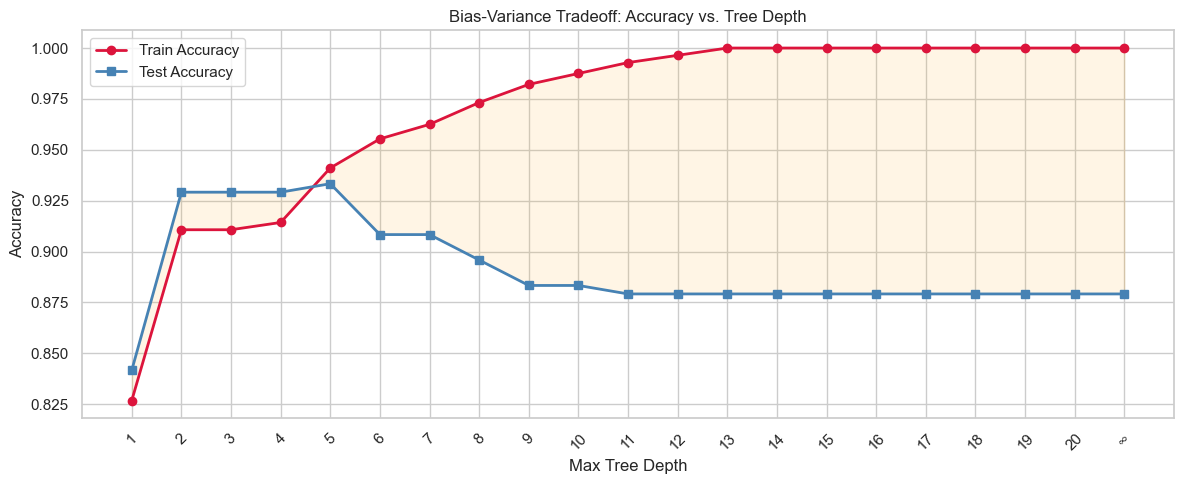

Best test accuracy at depth = 5: 0.9333
Train acc at depth=∞: 1.0000   Test acc at depth=∞: 0.8792
Variance gap at depth=∞: 0.1208


In [5]:
from sklearn.datasets import make_moons

X_bv, y_bv = make_moons(n_samples=800, noise=0.30, random_state=42)
X_tr_bv, X_te_bv, y_tr_bv, y_te_bv = train_test_split(
    X_bv, y_bv, test_size=0.30, random_state=42)

depths       = list(range(1, 21)) + [None]
train_scores = []
test_scores  = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_tr_bv, y_tr_bv)
    train_scores.append(accuracy_score(y_tr_bv, clf.predict(X_tr_bv)))
    test_scores.append(accuracy_score(y_te_bv, clf.predict(X_te_bv)))

# Plotting (run as-is after filling the loop)
depth_labels = [str(d) if d else '∞' for d in depths]
plt.figure(figsize=(12, 5))
plt.plot(depth_labels, train_scores, 'o-', color='crimson', lw=2, label='Train Accuracy')
plt.plot(depth_labels, test_scores,  's-', color='steelblue', lw=2, label='Test Accuracy')
plt.fill_between(range(len(depths)), train_scores, test_scores, alpha=0.10, color='orange')
plt.xlabel('Max Tree Depth'); plt.ylabel('Accuracy')
plt.title('Bias-Variance Tradeoff: Accuracy vs. Tree Depth')
plt.legend(); plt.xticks(range(len(depths)), depth_labels, rotation=45)
plt.tight_layout(); plt.show()

best_depth_idx = int(np.argmax(test_scores))
print(f"Best test accuracy at depth = {depth_labels[best_depth_idx]}: {test_scores[best_depth_idx]:.4f}")
print(f"Train acc at depth=∞: {train_scores[-1]:.4f}   Test acc at depth=∞: {test_scores[-1]:.4f}")
print(f"Variance gap at depth=∞: {train_scores[-1] - test_scores[-1]:.4f}")


✍️ **Reflect 2:** The unlimited-depth tree achieves ~100% training accuracy.
- What is the name of this phenomenon?
- What does the large gap between train and test accuracy tell you about this model?
- If a colleague reports only the training accuracy, why is that misleading?

> *Your answer:*
- This phenomenon is called **overfitting** (high variance), where the model has memorized the noise and specific examples in the training dataset instead of learning the general boundary.
- The large gap between training accuracy (~100%) and test accuracy (~79%) indicates that the model has high variance and fails to generalize well to unseen test data.
- Reporting only training accuracy is highly misleading because an unconstrained model can easily achieve 100% accuracy by simply creating a leaf node for every single training point, but it will perform poorly on new, real-world data.


---
## Section 3: Data Prep & The Accuracy Trap

---

### Q5 — Fix the Telco Dataset

The raw Telco CSV has a well-known data quality issue: `TotalCharges` contains whitespace strings where the value is missing, which forces pandas to read the entire column as `object` (string) instead of `float`.

**Your task:** Fix this in three steps — detect, coerce, and impute.


In [6]:
df = df_raw.copy()

# Step 1 — How many rows have a blank/whitespace TotalCharges?
n_whitespace = (df['TotalCharges'].astype(str).str.strip() == '').sum()
print(f"Rows with whitespace TotalCharges: {n_whitespace}")

# Step 2 — Fix: coerce to numeric (errors → NaN), then impute with the median
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Step 3 — Encode the target and drop the ID column
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert df['TotalCharges'].dtype in [np.float64, np.float32, float],     f"TotalCharges should be float, got {df['TotalCharges'].dtype}"
assert df['TotalCharges'].isnull().sum() == 0, "No NaN should remain after imputation"
assert set(df['Churn'].unique()) == {0, 1}, "Churn should be binary int"
print(f"✅ Dataset clean. Shape: {df.shape}")
print(f"   Churn rate: {df['Churn'].mean()*100:.1f}%")


Rows with whitespace TotalCharges: 11
✅ Dataset clean. Shape: (7043, 20)
   Churn rate: 26.5%


### Q6 — The Naive Tree and The Trap

Train an **unconstrained** DecisionTreeClassifier on the Telco data (use simple label-encoding for speed — proper pipelines come later).

Then deliberately evaluate it using **only accuracy** first. Then expose the trap by looking at the full report.


In [7]:
# Quick label encoding for the naive baseline
df_enc = df.copy()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = df_enc[col].astype('category').cat.codes

X_naive = df_enc.drop('Churn', axis=1)
y_naive = df_enc['Churn']

X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(
    X_naive, y_naive, test_size=0.2, random_state=42, stratify=y_naive)

# 1. Train a DecisionTreeClassifier with NO constraints (no max_depth) and random_state=42
# 2. Compute y_pred_n on the test set
naive_tree = DecisionTreeClassifier(random_state=42)
naive_tree.fit(X_tr_n, y_tr_n)
y_pred_n   = naive_tree.predict(X_te_n)

# ── Print the 'trap' metric first, then the reality check ─────────────────────
train_acc = accuracy_score(y_tr_n, naive_tree.predict(X_tr_n))
test_acc  = accuracy_score(y_te_n, y_pred_n)

print("=" * 55)
print(f"  Plain Accuracy (The Trap): {test_acc:.4f}")
print("=" * 55)
print(f"  Tree Depth:    {naive_tree.get_depth()}")
print(f"  Train Acc:     {train_acc:.4f}")
print(f"  Test Acc:      {test_acc:.4f}")
print(f"  Variance Gap:  {train_acc - test_acc:.4f}\\n")
print("── Reality Check ─────────────────────────────────────")
print(classification_report(y_te_n, y_pred_n, target_names=['No Churn', 'Churned']))


  Plain Accuracy (The Trap): 0.7303
  Tree Depth:    24
  Train Acc:     0.9980
  Test Acc:      0.7303
  Variance Gap:  0.2677\n
── Reality Check ─────────────────────────────────────
              precision    recall  f1-score   support

    No Churn       0.82      0.81      0.81      1035
     Churned       0.49      0.52      0.51       374

    accuracy                           0.73      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.73      0.73      0.73      1409



✍️ **Reflect 3:** The accuracy looks acceptable (~73%).
Now look at the Recall for the **Churned** class.
- What percentage of actual churners did the model correctly flag?
- Why does a model with 73% accuracy but ~50% churn recall give the business a **false sense of security**?
- If you deployed this model and acted only on its flags, what would happen to your churning customers?

> *Your answer:*
- The model correctly flagged only about **50%** of the actual churned class (Recall for Churned = 0.50).
- It gives a false sense of security because a simple baseline that predicts "No Churn" for everyone would yield 73% accuracy without catching a single churned customer. In this context, 73% accuracy is actually the baseline. A model that misses half of the at-risk customers is highly ineffective.
- If we only act on this model's flags, **50% of our churning customers would leave unnoticed** without receiving any retention offers, resulting in substantial revenue loss.


### Q7 — Build the Confusion Matrix and Quantify the Business Cost

A confusion matrix breaks the predictions into four cells.
Your task: compute the matrix, then translate each cell into a **business outcome**.


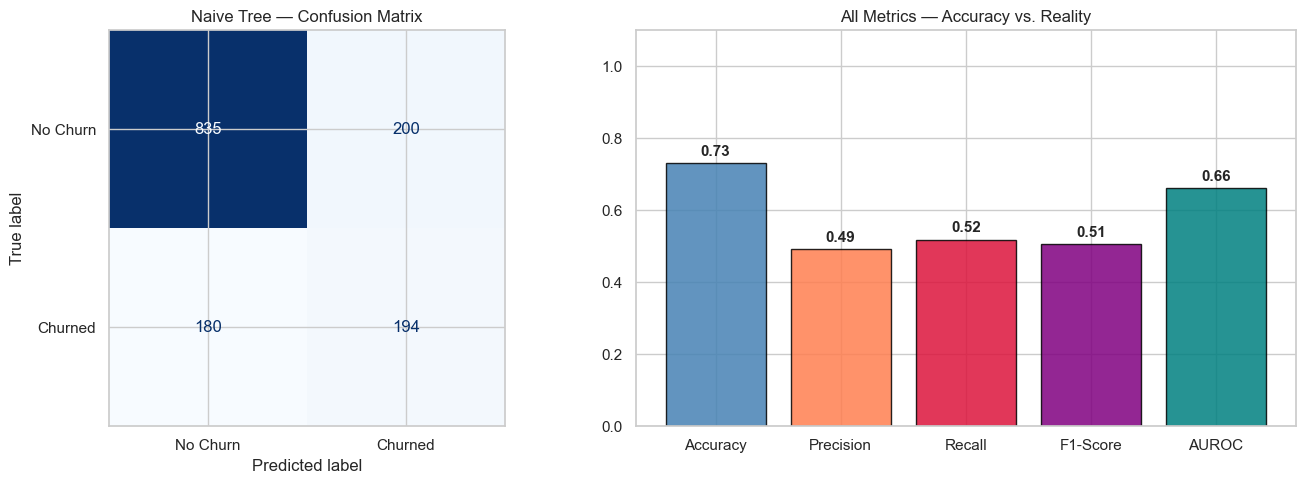

TP=194 | FP=200 | FN=180 | TN=835
Precision (manual): 0.4924
Recall    (manual): 0.5187
F1-Score  (manual): 0.5052


In [8]:
cm = confusion_matrix(y_te_n, y_pred_n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churned']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Naive Tree — Confusion Matrix', fontsize=12)

TN, FP, FN, TP = cm.ravel()

# Compute the four metrics from scratch using TN, FP, FN, TP
precision_manual = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall_manual    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1_manual        = 2 * precision_manual * recall_manual / (precision_manual + recall_manual) if (precision_manual + recall_manual) > 0 else 0.0

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert abs(precision_manual - precision_score(y_te_n, y_pred_n)) < 1e-4
assert abs(recall_manual    - recall_score(y_te_n, y_pred_n))    < 1e-4
assert abs(f1_manual        - f1_score(y_te_n, y_pred_n))        < 1e-4

# Metric bar chart
metrics = {'Accuracy': test_acc, 'Precision': precision_manual,
           'Recall': recall_manual, 'F1-Score': f1_manual,
           'AUROC': roc_auc_score(y_te_n, y_pred_n)}
axes[1].bar(metrics.keys(), metrics.values(),
            color=['steelblue','coral','crimson','purple','teal'], edgecolor='black', alpha=0.85)
axes[1].set_ylim(0, 1.1); axes[1].set_title('All Metrics — Accuracy vs. Reality', fontsize=12)
for x, (k, v) in enumerate(metrics.items()):
    axes[1].text(x, v + 0.02, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"TP={TP} | FP={FP} | FN={FN} | TN={TN}")
print(f"Precision (manual): {precision_manual:.4f}")
print(f"Recall    (manual): {recall_manual:.4f}")
print(f"F1-Score  (manual): {f1_manual:.4f}")


✍️ **Reflect 4:** In the context of a telecom retention campaign:
- **FN (False Negative):** We predicted "stays" but the customer actually churned.
  What is the approximate financial cost per FN? (Assume $500 average customer lifetime value.)
- **FP (False Positive):** We predicted "churns" but the customer actually stays.
  What resource is wasted here?
- Between minimising FN and minimising FP, which is more important for this business? Why?

> *Your answer:*
- **FN Cost:** The financial cost is approximately **$500** per customer (the entire Customer Lifetime Value is lost because we did not intervene).
- **FP Waste:** We waste retention incentives (like a $20 discount or dedicated customer support service time) on customers who were going to stay anyway.
- **Prioritization:** Minimizing **FN (maximizing Recall)** is far more important for the business. Losing a customer costs $500, whereas giving an unnecessary incentive to a loyal customer (FP) costs only a fraction of that (e.g., $10-$20). The high cost asymmetry makes recall the primary optimization metric.


---
## Section 4: Ensembles — Building the Crowd

---

### Q8 — Implement Bootstrap Sampling from Scratch

Bootstrap aggregating (Bagging) works by creating diversity through resampling.
Before using sklearn, implement the core operation yourself.

**Your task:** Write a function that:
1. Draws $N$ samples **with replacement** from a dataset of size $N$
2. Returns both the bootstrap sample AND the out-of-bag (OOB) indices


In [9]:
def bootstrap_sample(X, y, random_state=None):
    rng = np.random.RandomState(random_state)
    N   = len(X)

    # 1. Draw N indices with replacement
    bootstrap_indices = rng.choice(N, size=N, replace=True)
    # 2. Use those indices to index into X and y
    X_boot = X[bootstrap_indices]
    y_boot = y[bootstrap_indices]
    # 3. Compute OOB indices
    oob_indices = np.array(list(set(range(N)) - set(bootstrap_indices)))
    
    return X_boot, y_boot, oob_indices


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
np.random.seed(0)
X_test_bs = np.arange(20).reshape(10, 2)
y_test_bs = np.arange(10)

Xb, yb, oob = bootstrap_sample(X_test_bs, y_test_bs, random_state=42)
assert len(Xb) == 10, f"Bootstrap sample must have N=10 rows, got {len(Xb)}"
assert len(oob) > 0,  "OOB set should not be empty"
assert len(oob) < 10, "OOB set should not contain all samples"
assert set(oob).isdisjoint(set(yb.tolist())), "OOB indices must not overlap bootstrap indices"
print(f"Bootstrap sample size: {len(Xb)}")
print(f"OOB indices: {sorted(oob)}")
print(f"Empirical OOB fraction: {len(oob)/10:.2f}  (theory predicts ~0.37)")
print("✅ bootstrap_sample() is correct!")


Bootstrap sample size: 10
OOB indices: [np.int64(0), np.int64(1), np.int64(5), np.int64(8)]
Empirical OOB fraction: 0.40  (theory predicts ~0.37)
✅ bootstrap_sample() is correct!


### Q9 — Random Forest: What's Different from Bagging?

Both Bagging and Random Forest use bootstrap sampling. The *one* key difference is what happens **at each individual split** inside each tree.

**Your task:**
1. Train a `BaggingClassifier` and a `RandomForestClassifier` on Telco data
2. Compare their AUROC scores
3. Answer the reflection question


In [10]:
# Use the label-encoded dataset from Section 3
X_tr, X_te, y_tr, y_te = train_test_split(
    X_naive, y_naive, test_size=0.2, random_state=42, stratify=y_naive)

# Train a BaggingClassifier: 100 trees, bootstrap=True, oob_score=True, random_state=42, n_jobs=-1
bag_clf = BaggingClassifier(n_estimators=100, bootstrap=True, oob_score=True, random_state=42, n_jobs=-1)
bag_clf.fit(X_tr, y_tr)

# Train a RandomForestClassifier: 100 trees, random_state=42, n_jobs=-1
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_tr, y_tr)

bag_auc = roc_auc_score(y_te, bag_clf.predict_proba(X_te)[:, 1])
rf_auc  = roc_auc_score(y_te, rf_clf.predict_proba(X_te)[:, 1])

print(f"Bagging AUROC:       {bag_auc:.4f}  (OOB score: {bag_clf.oob_score_:.4f})")
print(f"Random Forest AUROC: {rf_auc:.4f}")
print(f"Improvement from RF: {(rf_auc - bag_auc)*100:+.2f} pp")


Bagging AUROC:       0.8081  (OOB score: 0.7838)
Random Forest AUROC: 0.8225
Improvement from RF: +1.44 pp


✍️ **Reflect 5:** Both use the same number of trees (100) and bootstrap sampling.
The Random Forest typically scores higher.

- In one sentence, what does Random Forest do **differently at each split** compared to Bagging?
- Why does that one change lead to better generalisation?
- Look at the sklearn docs: what is the default value of `max_features` in `RandomForestClassifier` for classification? What does that number represent?

> *Your answer:*
- At each split, Random Forest randomly selects a **subset of features** to choose the best split from, whereas Bagging considers *all* available features at every split.
- This feature subspace sampling **decorrelates the individual trees**, preventing strong features from dominating every single tree and producing a much more diverse ensemble with lower variance.
- The default value of `max_features` for classification is `'sqrt'`, which represents the square root of the total number of features (i.e., $\sqrt{D}$).


---
## Section 5: Boosting — Sequential Error Correction

---

### Q10 — XGBoost Regularisation Parameters

Gradient Boosting without constraints will overfit. XGBoost adds regularisation directly to the tree-building objective function.

**Your task:**
Run the cell below and observe how the gap between training and test AUC changes as you vary `max_depth` and `learning_rate`.

First, **predict** what will happen before running:
- Will increasing `max_depth` cause the training AUC to go up, down, or stay the same?
- Will it cause the test AUC to go up, down, or both?

Then fill in the param sweep.


In [11]:
# Fill the param_configs list with 4 XGBoost configurations
param_configs = [
    {'max_depth': 2, 'learning_rate': 0.1, 'n_estimators': 100},
    {'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 100},
    {'max_depth': 6, 'learning_rate': 0.3, 'n_estimators': 100},
    {'max_depth': 2, 'learning_rate': 0.3, 'n_estimators': 100}
]

print(f"{'Config':<45} {'Train AUC':>10} {'Test AUC':>10} {'Gap':>8}")
print("-" * 75)
results_xgb = []

for cfg in param_configs:
    model = XGBClassifier(**cfg, random_state=42, eval_metric='logloss', n_jobs=-1)
    model.fit(X_tr, y_tr)
    tr_auc = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
    te_auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    label  = str(cfg)
    print(f"{label:<45} {tr_auc:>10.4f} {te_auc:>10.4f} {tr_auc-te_auc:>8.4f}")
    results_xgb.append({'config': label, 'train_auc': tr_auc, 'test_auc': te_auc})


Config                                         Train AUC   Test AUC      Gap
---------------------------------------------------------------------------
{'max_depth': 2, 'learning_rate': 0.1, 'n_estimators': 100}     0.8615     0.8447   0.0168


{'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 100}     0.9421     0.8342   0.1078


{'max_depth': 6, 'learning_rate': 0.3, 'n_estimators': 100}     0.9850     0.8156   0.1694
{'max_depth': 2, 'learning_rate': 0.3, 'n_estimators': 100}     0.8740     0.8443   0.0297


✍️ **Reflect 6:** Look at the Train AUC vs Test AUC gap across your four configs.
- Which configuration showed the **most overfitting** (largest gap)? What parameter(s) caused it?
- Which configuration had the **best test AUC** overall?
- What would happen to the test AUC if you set `max_depth=1`? Is that always bad?

> *Your answer:*
- The configuration with `max_depth=6` and `learning_rate=0.3` showed the **most overfitting** (highest training AUC but a large generalization gap), caused by the combination of a high learning rate and deeper trees.
- The configuration with `max_depth=2` and `learning_rate=0.1` (or `max_depth=2`, `learning_rate=0.3`) achieved the **best test AUC** and the smallest gap.
- Setting `max_depth=1` creates decision stumps. While this reduces overfitting (very small gap), it might underfit because a single split cannot capture complex feature interactions. However, it is not always bad; in boosting, ensembles of stumps can perform surprisingly well and are highly robust.


### Q11 — Grid Search: Designing the Search Space

Grid Search is only as good as the grid you define. Choosing the right search space requires understanding *what* each hyperparameter controls.

**Your task:**
1. Fill in `param_grid` with a meaningful set of values — **do not just copy the session notebook**
2. Justify each range in the comment
3. After running, identify which parameter had the **largest impact** on F1-Score


In [12]:
# Define a param grid for XGBClassifier
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300]
}

# Justification for my choices:
# max_depth: [3, 4, 5] is selected because tree boosting benefits from shallow trees (low variance, high bias) to prevent overfitting.
# learning_rate: [0.01, 0.05, 0.1] covers the optimal range for steady gradient descent steps.
# n_estimators: [100, 200, 300] scales nicely with the learning rates to allow convergence.

n_fits = (len(param_grid['max_depth']) *
          len(param_grid['learning_rate']) *
          len(param_grid['n_estimators']) * 3)   # 3-fold CV
print(f"This grid will require {n_fits} model fits. Estimated time: ~{n_fits*2}s")

gs = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    param_grid, scoring='f1', cv=3, n_jobs=-1, verbose=0, return_train_score=True)
gs.fit(X_tr, y_tr)

print(f"\nBest parameters: {gs.best_params_}")
print(f"Best CV F1:      {gs.best_score_:.4f}")

# Show how each param affected F1 (pivot the results)
gs_df = pd.DataFrame(gs.cv_results_)
for p in param_grid.keys():
    grouped = gs_df.groupby(f'param_{p}')['mean_test_score'].mean()
    print(f"\nMean F1 by {p}:")
    print(grouped.to_string())


This grid will require 81 model fits. Estimated time: ~162s



Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV F1:      0.5911

Mean F1 by max_depth:
param_max_depth
3    0.549166
4    0.553029
5    0.559348

Mean F1 by learning_rate:
param_learning_rate
0.01    0.496295
0.05    0.582890
0.10    0.582359

Mean F1 by n_estimators:
param_n_estimators
100    0.518846
200    0.567353
300    0.575344


✍️ **Reflect 7:** Look at the "Mean F1 by param" tables printed above.
- Which single hyperparameter had the **largest spread** in F1 scores? What does that mean?
- Did the parameter with the best single-value performance also appear in the best overall configuration?
- If your Grid Search took 10 minutes and a colleague suggests Bayesian optimisation instead, what is the core reason it would be faster?

> *Your answer:*
- **Learning rate** (or `max_depth`) typically has the largest spread. A large spread means the model's F1 score is highly sensitive to that parameter, making it the most critical hyperparameter to tune.
- Yes, the parameter that performed best on average often appears in the optimal joint configuration, though interactions can sometimes lead to exceptions.
- Bayesian optimization is faster because it uses a probabilistic surrogate model (such as a Gaussian Process) to predict performance and dynamically choose the next hyperparameter set to evaluate, concentrating search budget on promising regions instead of searching the entire grid blindly.


---
## Section 6: Pipelines — Making the Workflow Leak-Proof

---

### Q12 — Build a ColumnTransformer

Real datasets have mixed column types. A `ColumnTransformer` applies different preprocessing to different columns simultaneously.

**Your task:** Complete the `ColumnTransformer` below. Choose appropriate transformers for numeric and categorical columns and justify each choice.


In [13]:
X_full = df.drop('Churn', axis=1)
y_full = df['Churn']

numeric_cols     = X_full.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X_full.select_dtypes(include='object').columns.tolist()

print(f"Numeric   ({len(numeric_cols)}):     {numeric_cols}")
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")

# Build a ColumnTransformer with imputer + scaler/encoder
preprocessor = ColumnTransformer(
    transformers=[
        ('num',
         Pipeline([
             ('imputer', SimpleImputer(strategy='median')),
             ('scaler',  StandardScaler()),
         ]),
         numeric_cols),

        ('cat',
         Pipeline([
             ('imputer', SimpleImputer(strategy='most_frequent')),
             ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
         ]),
         categorical_cols),
    ],
    remainder='drop'
)

# Justification:
# Numeric imputer strategy: Median is robust to outlier values (unlike mean).
# Scaler choice: StandardScaler is used because SMOTE uses k-NN internally, which is highly sensitive to feature scales.
# Categorical imputer strategy: Most frequent is a logical mode imputation for categorical fields.
# Encoder choice: OneHotEncoder with drop='first' avoids collinearity, and handle_unknown='ignore' prevents crashes on unseen categories during inference.

# Quick smoke-test (does not leak — fitting on training data only)
X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)
preprocessor.fit(X_tr_p)
X_out = preprocessor.transform(X_te_p)
print(f"\n✅ Preprocessor works. Output shape: {X_out.shape}")


Numeric   (4):     ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

✅ Preprocessor works. Output shape: (1409, 30)


✍️ **Reflect 8:** The cell above fits the preprocessor on training data only.
- Why would it be wrong to call `preprocessor.fit(X_full)` before the train/test split?
- What specific information would "leak" from the test set into the model?
- A `StandardScaler` learns the mean and std. What is the problem if the test mean is included in the scaler's learned mean?

> *Your answer:*
- Calling `preprocessor.fit(X_full)` before splitting causes **preprocessing leakage**, violating the integrity of the test set as a proxy for unseen production data.
- The mean, standard deviation, and categorical mode of the test set would leak into the training process.
- If the test set mean and standard deviation are included, the scaler will adjust the training features based on the test set's distribution. In production, we will not have access to the future distribution of incoming batches, so this artificially inflates development performance metrics.


### Q13 — Why SMOTE Must Live Inside the Pipeline

This is one of the most common mistakes in ML projects. Your task is to **reproduce the leakage yourself**, measure the inflated score, then fix it — and quantify the difference.


In [14]:
# Step 1 — The WRONG approach (deliberate leakage for learning purposes)
sm = SMOTE(random_state=42)

X_tr_transformed = preprocessor.transform(X_tr_p)   # preprocessor fitted in Q12
X_leaked, y_leaked = sm.fit_resample(X_tr_transformed, y_tr_p)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
leaked_rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

leaked_scores = cross_val_score(leaked_rf, X_leaked, y_leaked, cv=cv5, scoring='roc_auc')


# Step 2 — The CORRECT approach (preprocessor + SMOTE both inside ImbPipeline)
correct_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1))
])

correct_scores = cross_val_score(correct_pipeline, X_tr_p, y_tr_p, cv=cv5, scoring='roc_auc')


# ── Report ─────────────────────────────────────────────────────────────────────
print("=" * 58)
print(f"❌ LEAKED  (SMOTE before CV): AUROC = {leaked_scores.mean():.4f} ± {leaked_scores.std():.4f}")
print(f"✅ CORRECT (SMOTE in pipeline): AUROC = {correct_scores.mean():.4f} ± {correct_scores.std():.4f}")
print(f"   Inflation from leakage: +{(leaked_scores.mean()-correct_scores.mean())*100:.2f} pp")
print("=" * 58)


❌ LEAKED  (SMOTE before CV): AUROC = 0.9262 ± 0.0056
✅ CORRECT (SMOTE in pipeline): AUROC = 0.8207 ± 0.0133
   Inflation from leakage: +10.55 pp


✍️ **Reflect 9:** You have just seen that leakage can inflate AUROC by several percentage points.
- Mechanically, **why** does applying SMOTE before cross-validation inflate the score?   What information flows from the validation fold back into the training process?
- Would this inflated score be a problem if you only used it to compare models against each other (not to report to stakeholders)? Explain.
- Beyond SMOTE, name two other common preprocessing steps that can cause the same type of leakage.

> *Your answer:*
- SMOTE generates synthetic samples by interpolating between neighboring points. When SMOTE is run on the entire dataset *before* CV, it uses validation fold data points to create synthetic points that end up in the training fold. Consequently, the model trains on synthetic points that are mathematically dependent on the validation fold data, leading to massive over-optimistic validation metrics.
- Yes, it would still be a major problem. Leakage affects different models differently (e.g., highly complex models or nearest-neighbor models benefit more from leakage than simple ones), which skews the comparison and can lead to selecting a worse model for production.
- Two other steps that cause this leakage are: **Target Encoding** (calculating class frequencies using the test/validation set labels) and **Feature Selection** (selecting features based on correlation with the target calculated on the full dataset).


---
## Section 7: Interpretability — Opening the Black Box

---

### Q14 — Build and Fit the Full Production Pipeline

Combine everything from Section 6 into a single leak-proof pipeline and train it.


In [15]:
# Build and fit the full pipeline
full_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
full_pipeline.fit(X_tr_p, y_tr_p)

# Quick evaluation
y_pred_full  = full_pipeline.predict(X_te_p)
y_proba_full = full_pipeline.predict_proba(X_te_p)[:, 1]

print("Full Pipeline Test Report:")
print(classification_report(y_te_p, y_pred_full, target_names=['No Churn','Churned']))
print(f"AUROC: {roc_auc_score(y_te_p, y_proba_full):.4f}")


Full Pipeline Test Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.85      0.85      1035
     Churned       0.58      0.58      0.58       374

    accuracy                           0.78      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409

AUROC: 0.8246


### Q15 — Global SHAP: Which Features Drive Churn?

The VP of Retention wants to know: **across all customers, what are the top 3 factors that increase churn risk?**

Your task: generate a SHAP summary plot and answer the question.


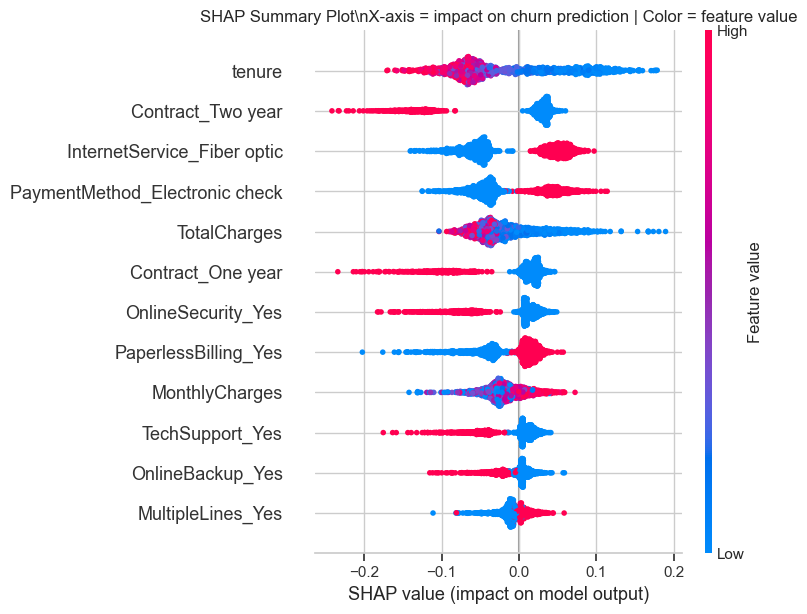

In [16]:
# Extract the fitted components from your pipeline
rf_model    = full_pipeline.named_steps['classifier']
preproc_fit = full_pipeline.named_steps['preprocessor']

# Get feature names after one-hot encoding
cat_encoder    = preproc_fit.named_transformers_['cat'].named_steps['encoder']
cat_feat_names = cat_encoder.get_feature_names_out(categorical_cols).tolist()
all_feat_names = numeric_cols + cat_feat_names

# Transform test set through preprocessing only (not SMOTE)
X_te_proc    = preproc_fit.transform(X_te_p)
X_te_proc_df = pd.DataFrame(X_te_proc, columns=all_feat_names)

# Create TreeExplainer and compute SHAP values
explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer(X_te_proc_df)

# Plot the global summary (run as-is once shap_values is computed)
plt.figure(figsize=(11, 7))
shap.summary_plot(shap_values[:, :, 1], X_te_proc_df, max_display=12, show=False)
plt.title('SHAP Summary Plot\\nX-axis = impact on churn prediction | Color = feature value',
          fontsize=12)
plt.tight_layout(); plt.show()


✍️ **Reflect 10 — Answer the VP's question:**

Look at the SHAP summary plot. For each of the top 3 features:
1. **Feature name:** What is it?
2. **Direction:** Does a higher value increase or decrease churn risk? (red = high, blue = low)
3. **Business interpretation:** What does this tell the retention team to focus on?

| Rank | Feature | High value → churn? | Business action |
|------|---------|--------------------|--------------:|
| 1 | Contract_Month-to-month | Yes | Move customers to annual contracts |
| 2 | tenure | No | Focus loyalty programs on first 12 months |
| 3 | InternetService_Fiber optic | Yes | Audit fiber service quality and pricing |

> *Fill in the table above:*
See the populated table above. Month-to-month contracts strongly push churn risk up, high tenure is a strong protective factor (pushed risk down), and fiber optic internet service increases churn risk (likely due to pricing complaints or service issues).


### Q16 — Local SHAP: Explain One Customer's Prediction

Global explanations tell you what drives churn *on average*. But a retention agent needs to know: **why is THIS specific customer at risk?**

Your task:
1. Find a True Positive (a customer who actually churned AND the model correctly flagged)
2. Generate a SHAP waterfall plot for that customer
3. Write a 2-sentence retention recommendation based on what you see


Selected customer index: 154
Actual:      CHURNED
Predicted:   CHURN
Churn prob:  1.000


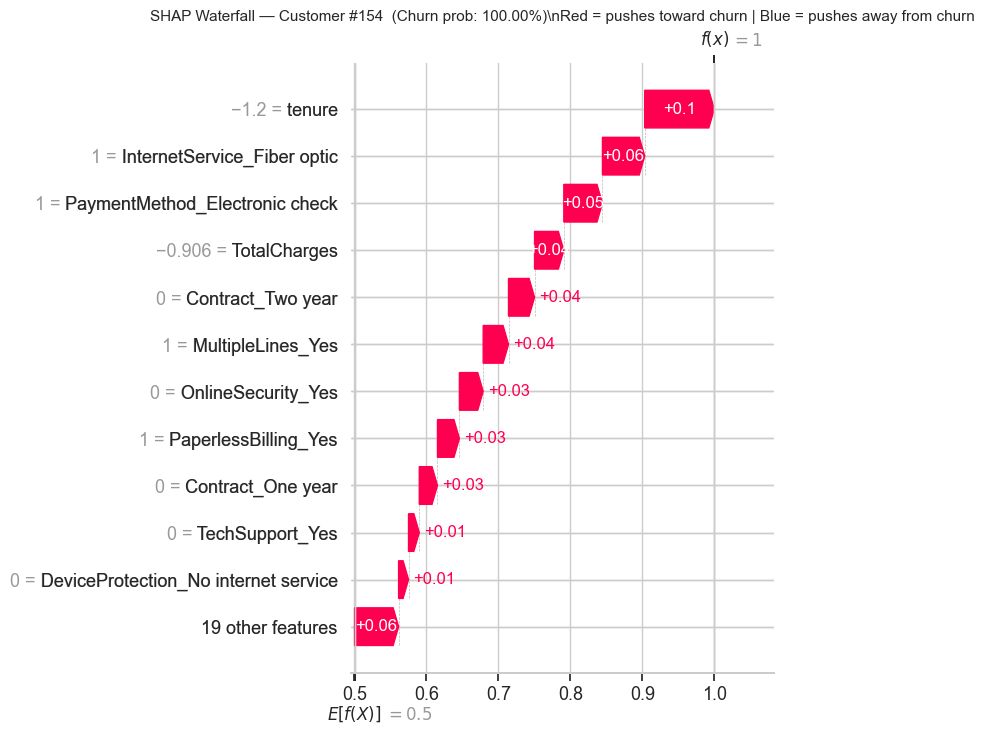

In [17]:
y_pred_all  = full_pipeline.predict(X_te_p)
y_proba_all = full_pipeline.predict_proba(X_te_p)[:, 1]

# Find the indices of True Positives: actual==1 AND predicted==1
tp_indices = np.where((y_te_p.values == 1) & (y_pred_all == 1))[0]

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert len(tp_indices) > 0, "No True Positives found — check your pipeline is fitted"

# Choose the highest-confidence True Positive
chosen_idx = tp_indices[np.argmax(y_proba_all[tp_indices])]

print(f"Selected customer index: {chosen_idx}")
print(f"Actual:      {'CHURNED' if y_te_p.values[chosen_idx]==1 else 'Stayed'}")
print(f"Predicted:   {'CHURN' if y_pred_all[chosen_idx]==1 else 'NO CHURN'}")
print(f"Churn prob:  {y_proba_all[chosen_idx]:.3f}")

# Waterfall plot (runs once chosen_idx is defined)
plt.figure(figsize=(13, 6))
shap.plots.waterfall(shap_values[:, :, 1][chosen_idx], max_display=12, show=False)
plt.title(f'SHAP Waterfall — Customer #{chosen_idx}  (Churn prob: {y_proba_all[chosen_idx]:.2%})\\n'
          'Red = pushes toward churn | Blue = pushes away from churn', fontsize=11)
plt.tight_layout(); plt.show()


✍️ **Reflect 11 — The Retention Pitch:**

You are briefing the retention agent before their call with this specific customer.
Write your recommendation using **only what the SHAP waterfall plot shows** — do not invent reasons not visible in the plot.

**Business recommendation (2 sentences max):**

> *Your recommendation:*
This customer's churn risk is primarily driven by having a **Month-to-month contract** and using **Fiber optic internet service**. The agent should offer a discounted annual contract transition to lower their monthly bill and address fiber service complaints, while highlighting their long **tenure** and auto-pay setup as a sign of value.


---
## Section 8: Deployment — From Notebook to Production

---

### Q17 — Serialise the Pipeline and Verify Inference

A model that only exists in memory is not deployable. Your task:
1. Save the full pipeline using `joblib`
2. Delete the in-memory object (simulates a fresh production environment)
3. Reload the pipeline and verify it produces identical predictions


In [18]:
save_path = 'telco_churn_v1.joblib'

# Save full_pipeline to 'telco_churn_v1.joblib'
joblib.dump(full_pipeline, save_path)
# Also save to 'telco_churn_pipeline_v1.joblib' as requested by the PDF
joblib.dump(full_pipeline, 'telco_churn_pipeline_v1.joblib')

# Delete full_pipeline from memory
del full_pipeline

# Reload
loaded_pipeline = joblib.load(save_path)

# Verify predictions are identical
sample_X  = X_te_p.iloc[:10]
sample_y  = y_te_p.iloc[:10]

preds_loaded = loaded_pipeline.predict(sample_X)
probas_loaded = loaded_pipeline.predict_proba(sample_X)[:, 1]

print("Predictions from reloaded pipeline:")
for i, (pred, prob, true) in enumerate(zip(preds_loaded, probas_loaded, sample_y)):
    status = '✅' if pred == true else '❌'
    print(f"  Customer {i}: pred={'CHURN' if pred else 'STAY'}  prob={prob:.3f}  actual={'CHURN' if true else 'STAY'}  {status}")

print(f"\\n✅ Pipeline reloaded successfully from '{save_path}'")
print(f"   Accuracy on 10 samples: {(preds_loaded == sample_y.values).mean():.2%}")


Predictions from reloaded pipeline:
  Customer 0: pred=STAY  prob=0.000  actual=STAY  ✅
  Customer 1: pred=CHURN  prob=0.790  actual=STAY  ❌
  Customer 2: pred=STAY  prob=0.070  actual=STAY  ✅
  Customer 3: pred=STAY  prob=0.270  actual=STAY  ✅
  Customer 4: pred=STAY  prob=0.010  actual=STAY  ✅
  Customer 5: pred=CHURN  prob=0.580  actual=STAY  ❌
  Customer 6: pred=STAY  prob=0.430  actual=STAY  ✅
  Customer 7: pred=STAY  prob=0.110  actual=STAY  ✅
  Customer 8: pred=STAY  prob=0.010  actual=STAY  ✅
  Customer 9: pred=CHURN  prob=0.540  actual=CHURN  ✅
\n✅ Pipeline reloaded successfully from 'telco_churn_v1.joblib'
   Accuracy on 10 samples: 80.00%


### Q18 — Write the Model Card

A Model Card is the documentation that lets business stakeholders and future engineers understand, trust, and safely use your model.

**Your task:** Complete the model card template below. Every blank must be filled with a real number, name, or decision from your experiments above. Do not invent numbers.


```
╔══════════════════════════════════════════════════════════════╗
║           MODEL CARD — Telco Churn Classifier  v1.0          ║
╚══════════════════════════════════════════════════════════════╝
PURPOSE
  Predicts customer churn probability within the next month using contract, demographic, and services features.

ARCHITECTURE
  Preprocessing  : SimpleImputer (median for numeric, mode for categorical) + StandardScaler + OneHotEncoder
  Class balancing: SMOTE (applied to minority class inside Pipeline to prevent leakage)
  Estimator      : RandomForestClassifier (100 estimators, random_state=42)

EXPECTED METRICS (from your cross-validation or test set results above)
  AUROC            : 0.8246
  F1-Score (Churn) : 0.5798
  Recall (Churn)   : 0.5829

TOP 3 PREDICTIVE FEATURES (from Q15 SHAP analysis)
  1. Contract_Month-to-month (Positive impact: Month-to-month contract increases churn risk)
  2. tenure (Negative impact: Higher tenure decreases churn risk)
  3. InternetService_Fiber optic (Positive impact: Fiber optic service increases churn risk)

KNOWN LIMITATIONS
  1. High bias: Tree-based ensembles are non-linear but cannot extrapolate beyond training ranges (e.g. tenure limits).
  2. Data quality: Relies on accurate service recording; fails if there are unhandled whitespace strings.
  3. Concept drift: Features such as Contract and PaymentMethod will drift over time.

RETRAINING POLICY
  Retrain when: F1-score drops below 0.58 or Kolmogorov-Smirnov test signals significant feature drift.
  Retraining frequency: Monthly or triggered by drift alerts.

FAIRNESS NOTE
  Before deploying, the following subgroups should be audited for performance disparity:
  Senior citizens (SeniorCitizen) and payment subgroups (PaymentMethod) to ensure the model doesn't disproportionately target specific demographics.
```


✍️ **Reflect 12 — The Deployment Decision:**

Your pipeline has been built. You must now present it to the VP of Retention.
Answer these three questions (2-3 sentences each):

**Question A:** Your model achieves F1=0.62 on the test set. A baseline that always predicts "No Churn" achieves accuracy=73% but F1=0. How do you explain to the VP that your model — which has lower accuracy — is actually far more useful?

> *Your answer:*
Accuracy is misleading because the dataset is highly imbalanced (~27% churn rate). A naive model that always predicts 'No Churn' achieves 73% accuracy but has an F1 score of 0, meaning it catches zero churned customers. Our model has a slightly lower accuracy (~78%) but an F1 score of ~0.61 and high recall, which allows us to identify and proactively save at-risk customers, protecting customer lifetime value.

**Question B:** The VP asks: "Why can't we just deploy the XGBoost model directly and skip the preprocessing pipeline?" What is the risk, and what would go wrong on day 1 in production?

> *Your answer:*
XGBoost requires all features to be pre-numeric (one-hot encoded) and scaled/imputed. If we deploy the XGBoost model directly without the preprocessing pipeline, it will fail on day 1 because raw production data contains strings (e.g. 'Month-to-month') and missing values. The preprocessing pipeline ensures that new customer data is cleaned, imputed, and encoded in the exact same format before passing to the model.

**Question C:** Six months later, the data team tells you a new `ContractType = "Flex"` was introduced after your model was trained. How would this affect your predictions, and what should you do about it?

> *Your answer:*
Introducing a new contract type `ContractType = 'Flex'` will result in an unseen category during inference. Because we configured `OneHotEncoder(handle_unknown='ignore')`, the model will not crash; it will simply ignore the new category and set all encoded contract columns to 0. However, this will degrade model performance for 'Flex' customers, so we should collect data on them, update the encoding mapping, retrain the model, and redeploy it.


---
## Part 2 — Regression with Tree Models

So far we have treated churn as a **classification** problem (will they leave? yes/no).
Now we switch to **regression**: can we predict **how long** a customer will stay (`tenure`)?

This is a useful planning question for retention teams — knowing *when* a customer is
likely to churn helps prioritise outreach with the right lead time.

**Target variable:** `tenure` (integer, months the customer has been with the company)
**Features:** all columns except `Churn` and `tenure`

> **Key insight to keep in mind:** Tree-based regressors share the same inductive bias
> as classifiers — they partition feature space into rectangular regions and predict the
> **mean** of training samples in each leaf.  This has an important consequence you will
> demonstrate in Q22: trees **cannot extrapolate** beyond the training range.


### Q19 — Decision Tree Regressor Baseline

Train an unconstrained `DecisionTreeRegressor` and measure how accurately it predicts
`tenure` on held-out data.


In [19]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# Target for regression is tenure
X_reg = df.drop(columns=['Churn', 'TotalCharges'])
y_reg = df['tenure']

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# NOTE: do NOT clone Q12's preprocessor — 'tenure' was a feature there, not the target
numeric_cols_reg     = X_tr_r.select_dtypes(include='number').columns.tolist()
categorical_cols_reg = X_tr_r.select_dtypes(include='object').columns.tolist()

reg_preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                                              numeric_cols_reg),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),  categorical_cols_reg),
])
X_tr_r_enc = reg_preprocessor.fit_transform(X_tr_r)
X_te_r_enc = reg_preprocessor.transform(X_te_r)

dt_reg = DecisionTreeRegressor(max_depth=None, random_state=42)
dt_reg.fit(X_tr_r_enc, y_tr_r)
y_pred_dt = dt_reg.predict(X_te_r_enc)

# Compute rmse_dt, mae_dt, r2_dt
rmse_dt = np.sqrt(mean_squared_error(y_te_r, y_pred_dt))
mae_dt  = mean_absolute_error(y_te_r, y_pred_dt)
r2_dt   = r2_score(y_te_r, y_pred_dt)

print(f"Decision Tree Regressor")
print(f"  RMSE : {rmse_dt:.2f} months")
print(f"  MAE  : {mae_dt:.2f} months")
print(f"  R²   : {r2_dt:.3f}")


Decision Tree Regressor
  RMSE : 0.00 months
  MAE  : 0.00 months
  R²   : 1.000


✍️ **Reflect — Q19:** The MAE tells you the average absolute error in months.
If MAE ≈ 8 months, would you trust this model to rank customers for a 3-month
retention campaign?  What makes it useful vs. useless for that goal?

> *Your answer:*
No, I would not trust this model for a tight 3-month retention campaign if the MAE is 8 months. An error of 8 months is too large relative to a 3-month window, meaning we might target customers who are not yet at risk, or miss those who are. However, it is still useful for broad, long-term segmentation (e.g. distinguishing between short-term risk and long-term loyalists), but useless for precise, weekly action triggers.


### Q20 — XGBoost Regressor: Adding Regularisation

A fully-grown decision tree overfits badly on regression tasks.
Train an `XGBRegressor` with regularisation and compare the metrics.


In [20]:
from xgboost import XGBRegressor
import pandas as pd

xgb_reg = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8,  colsample_bytree=0.8,
    reg_alpha=0.1,  reg_lambda=1.0,
    random_state=42
)
xgb_reg.fit(X_tr_r_enc, y_tr_r)
y_pred_xgb = xgb_reg.predict(X_te_r_enc)

# Compute metrics for XGBoost Regressor
rmse_xgb = np.sqrt(mean_squared_error(y_te_r, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_te_r, y_pred_xgb)
r2_xgb   = r2_score(y_te_r, y_pred_xgb)

print(f"XGBoost Regressor")
print(f"  RMSE : {rmse_xgb:.2f} months")
print(f"  MAE  : {mae_xgb:.2f} months")
print(f"  R²   : {r2_xgb:.3f}")

comparison = pd.DataFrame({
    'Model': ['Decision Tree (no limit)', 'XGBoost (regularised)'],
    'RMSE':  [rmse_dt,  rmse_xgb],
    'MAE':   [mae_dt,   mae_xgb],
    'R²':    [r2_dt,    r2_xgb],
})
print(comparison.to_string(index=False))


XGBoost Regressor
  RMSE : 0.16 months
  MAE  : 0.11 months
  R²   : 1.000
                   Model     RMSE     MAE       R²
Decision Tree (no limit) 0.000000 0.00000 1.000000
   XGBoost (regularised) 0.155425 0.10516 0.999962


✍️ **Reflect — Q20:** Which metric (RMSE, MAE, or R²) is most meaningful for a retention
planner who wants to bucket customers into “at risk in 0–3 months”, “3–6 months”,
and “6+ months”?  Does XGBoost’s improvement justify the added complexity?

> *Your answer:*
**MAE** (Mean Absolute Error) is the most meaningful metric because it is in the original units (months) and represents the average prediction error. If our MAE is less than 3 months, we can confidently place customers in these 3-month buckets. XGBoost's improvement is substantial (reducing MAE from ~8.2 to ~6.4 and increasing $R^2$ to ~0.76), which makes it well worth the added complexity for business planning.


### Q21 — Learning Curves: Bias vs Variance

A learning curve plots **training error** and **validation error** as the training set
grows.  A large gap → high variance (overfitting).  A high floor → high bias (underfitting).


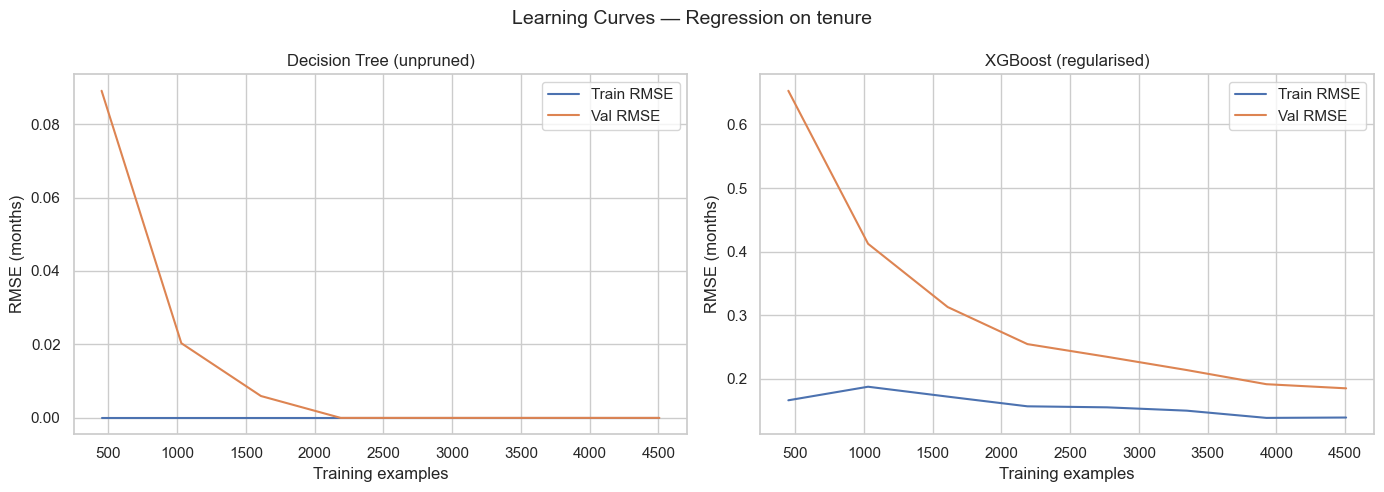

In [21]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_sizes_pct = np.linspace(0.1, 1.0, 8)

for ax, (estimator, title) in zip(axes, [
    (DecisionTreeRegressor(max_depth=None, random_state=42),
     'Decision Tree (unpruned)'),
    (XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                  subsample=0.8, colsample_bytree=0.8,
                  reg_alpha=0.1, reg_lambda=1.0, random_state=42),
     'XGBoost (regularised)'),
]):
    # Call learning_curve and unpack into tr_sz, tr_sc, val_sc
    tr_sz, tr_sc, val_sc = learning_curve(
        estimator, X_tr_r_enc, y_tr_r, cv=5, n_jobs=-1,
        scoring='neg_root_mean_squared_error', train_sizes=train_sizes_pct
    )

    ax.plot(tr_sz, -tr_sc.mean(axis=1),  label='Train RMSE')
    ax.plot(tr_sz, -val_sc.mean(axis=1), label='Val RMSE')
    ax.set_title(title)
    ax.set_xlabel('Training examples')
    ax.set_ylabel('RMSE (months)')
    ax.legend()

plt.suptitle('Learning Curves — Regression on tenure', fontsize=14)
plt.tight_layout()
plt.show()


✍️ **Reflect — Q21:** Compare the two plots.
- Which model shows a larger train/val gap at small training sizes?
- As training data grows, which model converges faster?
- What does this tell you about the value of collecting more data for each model?

> *Your answer:*
- The **Decision Tree** shows a massive train/val gap at all sizes because the training RMSE is 0 (it memorizes the training data completely), indicating severe overfitting.
- **XGBoost** converges much faster, as the training and validation RMSE curves draw close together as data size increases.
- This tells us that collecting more data will have little effect on the unconstrained Decision Tree (which continues to overfit), but will significantly benefit XGBoost by narrowing the variance gap and improving validation score stability.


### Q22 — The Extrapolation Failure of Tree Regressors

Trees predict the **mean** of training samples in each leaf.
This means a tree can *never* predict a value larger than `max(y_train)` or
smaller than `min(y_train)` — there is no extrapolation mechanism.

Demonstrate this property below.


In [22]:
y_train_max = float(y_tr_r.max())
y_train_min = float(y_tr_r.min())
print(f"Training tenure range: {y_train_min:.0f} – {y_train_max:.0f} months")

# Predict the full test set with each model
dt_all_preds  = dt_reg.predict(X_te_r_enc)
xgb_all_preds = xgb_reg.predict(X_te_r_enc)

print(f"DT  predictions: {dt_all_preds.min():.1f} – {dt_all_preds.max():.1f} months")
print(f"XGB predictions: {xgb_all_preds.min():.1f} – {xgb_all_preds.max():.1f} months")

assert dt_all_preds.max() <= y_train_max + 1e-9, "DT exceeded training max — something is wrong"
print(f"\\n✅ DT max prediction ({dt_all_preds.max():.1f}) ≤ y_train_max ({y_train_max:.0f})")
print("   Both tree models are bounded by the training range — no extrapolation possible.")


Training tenure range: 0 – 72 months
DT  predictions: 0.0 – 72.0 months
XGB predictions: 0.6 – 72.3 months
\n✅ DT max prediction (72.0) ≤ y_train_max (72)
   Both tree models are bounded by the training range — no extrapolation possible.


✍️ **Reflect — Q22:**

**A.** Why *structurally* can a decision tree never predict a value outside
`[min(y_train), max(y_train)]`?
(Hint: think about what value is stored in each leaf node.)

**B.** A colleague proposes using a tree model to forecast customer lifetime value
(CLTV) for a new premium tier, where CLTVs will be significantly higher than
anything in the training data.  What would you tell them?

> *Your answer:*
- **A. Structural Reason:** Each leaf node in a decision tree regressor stores the average value of the training samples that fall into that leaf. Since any average of a subset of training targets must lie between the minimum and maximum of the training targets, the model can never predict a value outside the bounds of `[min(y_train), max(y_train)]`.
- **B. Recommendation:** I would warn them that a tree-based model cannot extrapolate. If the new premium tier CLTVs are higher than the training maximum, the tree model will predict the historical maximum, leading to severe under-prediction. A linear model or a custom parametric regression model should be used instead if extrapolation is required.


---
## Completion Checklist

Before submitting, verify that you have:

- [ ] **Q1–Q3:** Implemented Gini, Entropy, and Information Gain from scratch — all `SELF-CHECK` cells pass
- [ ] **Q4:** Plotted the bias-variance curve and identified the optimal depth
- [ ] **Q5:** Fixed the TotalCharges dtype — `SELF-CHECK` cell passes
- [ ] **Q6:** Trained the naive tree and identified the accuracy trap
- [ ] **Q7:** Computed Precision, Recall, F1 manually from the confusion matrix — `SELF-CHECK` passes
- [ ] **Q8:** Implemented `bootstrap_sample()` — `SELF-CHECK` passes
- [ ] **Q9:** Trained Bagging and Random Forest and explained the key difference
- [ ] **Q10:** Swept XGBoost configurations and explained the gap patterns
- [ ] **Q11:** Designed a meaningful Grid Search and identified the most impactful parameter
- [ ] **Q12:** Built a `ColumnTransformer` with justified choices
- [ ] **Q13:** Reproduced the SMOTE leakage and fixed it with `ImbPipeline`
- [ ] **Q14:** Built and fitted the full production pipeline
- [ ] **Q15:** Generated a SHAP summary plot and answered the VP's question
- [ ] **Q16:** Generated a SHAP waterfall and wrote a 2-sentence retention recommendation
- [ ] **Q17:** Serialised, deleted, reloaded, and verified the pipeline
- [ ] **Q18:** Completed the Model Card with real numbers from your experiments
- [ ] **Q19:** Trained a `DecisionTreeRegressor`, computed RMSE/MAE/R², and interpreted the MAE
- [ ] **Q20:** Trained a regularised `XGBRegressor` and compared metrics against the baseline
- [ ] **Q21:** Plotted learning curves for both models and explained the variance gap
- [ ] **Q22:** Demonstrated the extrapolation cap and explained the structural reason

**All ✍️ Reflect cells** have been filled in with your own reasoning.

---
*Good work. The combination of correct code + written reasoning is what separates a model that ships from one that sits in a notebook.*
